# Spectral Template Analysis

This notebook:
1. Loads a trained checkpoint
2. Finds the best-fit redshift and amplitudes for a selection of galaxies
3. Plots observed spectra with template fits
4. Compares the recovered n(z) with the true redshift histogram

In [3]:
import sys, os, glob, json
sys.path.insert(0, '../py')

# JAX GPU memory: allocate on demand instead of preallocating most VRAM.
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from spectra_loader import SpectraDataset
from template_model import TemplateModel
from neural_template_model import NeuralTemplateModel

print('JAX devices:', jax.devices())
print('XLA_PYTHON_CLIENT_PREALLOCATE =', os.environ.get('XLA_PYTHON_CLIENT_PREALLOCATE'))

JAX devices: [CudaDevice(id=0)]
XLA_PYTHON_CLIENT_PREALLOCATE = false


## Configuration

In [59]:
# ---- Paths (adjust as needed) -----------------------------------------------
SPECTRA_DIR    = '../spectra_shuffled/'
ZERR_CATALOG   = '../metadata/desi-galaxy-cat-zerr.fits'
CHECKPOINT_DIR = '../checkpoints/'

# Galaxy selection
N_GALAXIES     = 2000    # number of galaxies to analyse
ZMIN           = 0.75
ZMAX           = 1.00
DESI_TARGET_MASK = None  # set to e.g. 1 to select a specific target class

# n(z) shaping (rejection sampling)
SHAPE_NOFZ  = True  # set True to rejection-sample to target n(z)
NOFZ_Z0     = 0.88
NOFZ_ALPHA  = 40.0
NOFZ_BETA   = 40.0

NOISE_MULT = 8

# Plotting
N_PLOT = 8   # number of example spectra to plot


## Load galaxy data

In [60]:
ds = SpectraDataset(
    SPECTRA_DIR,
    zerr_catalog=ZERR_CATALOG,
    n_spectra=N_GALAXIES,
    zmin=ZMIN,
    zmax=ZMAX,
    desi_target_mask=DESI_TARGET_MASK,
    shape_nofz=SHAPE_NOFZ,
    nofz_z0=NOFZ_Z0,
    nofz_alpha=NOFZ_ALPHA,
    nofz_beta=NOFZ_BETA,
    noise_mult=NOISE_MULT
)
print(f'{len(ds)} galaxies loaded')

# Load all into memory as JAX arrays
all_flux   = np.stack([ds[i]['flux'].numpy()  for i in range(len(ds))])
all_ivar   = np.stack([ds[i]['ivar'].numpy()  for i in range(len(ds))])
all_z      = np.array([ds[i]['z'].item()      for i in range(len(ds))])
all_zerr   = np.array([ds[i]['zerr'].item()   for i in range(len(ds))])

flux   = jnp.array(all_flux)
ivar   = jnp.array(all_ivar)
z_prior = jnp.array(all_z)
zerr    = jnp.array(all_zerr)

  shape_nofz: kept 64,450 / 252,848 spectra (25.5%)
2000 galaxies loaded


## Load checkpoint

In [85]:
# Find the latest checkpoint
ckpt_files = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, 'checkpoint_epoch*.npz')))
if not ckpt_files:
    raise FileNotFoundError(
        f'No checkpoints found in {CHECKPOINT_DIR}. '
        'Run scripts/train.py first.'
    )
ckpt_path = ckpt_files[-1]
print(f'Loading: {ckpt_path}')

# We need wave_obs before loading; read it from the first spectra file
import fitsio
first_file = sorted(glob.glob(os.path.join(SPECTRA_DIR, 'spec-*.fits')))[0]
with fitsio.FITS(first_file) as f:
    wave_obs = f['wave'].read().astype(np.float32)

# Detect checkpoint type from config
_ckpt_probe = np.load(ckpt_path, allow_pickle=True)
_cfg = json.loads(str(_ckpt_probe['config']))
if _cfg.get('model_type') == 'neural':
    model, params, epoch = NeuralTemplateModel.load_checkpoint(ckpt_path, wave_obs)
else:
    model, params, epoch = TemplateModel.load_checkpoint(ckpt_path, wave_obs)

print(f'Loaded {type(model).__name__} epoch {epoch}: Nt={model.Nt}, Nz={model.Nz}, '
      f'z=[{model.zmin:.2f}, {model.zmax:.2f}]')
print (params.keys())

Loading: ../checkpoints/checkpoint_epoch0399.npz
Loaded TemplateModel epoch 399: Nt=3, Nz=1000, z=[0.75, 1.00]
dict_keys(['T', 'log_nz_raw', 'alpha_flow'])


## Compute z posteriors and best-fit redshifts

In [86]:
# log_posterior shape: (N, Nz)
Ncompute = N_GALAXIES  # number of galaxies to compute posterior for (adjust as needed)
compute_posterior = jax.jit(model.compute_z_posterior)

# non-informative prior
z_prior_eval = jnp.full((len(ds),), (model.zmin + model.zmax) / 2.0)
zerr_eval    = jnp.full((len(ds),), 100.0)

log_post = compute_posterior(params, flux[:Ncompute], ivar[:Ncompute], z_prior_eval[:Ncompute], zerr_eval[:Ncompute])
log_post_np = np.array(log_post)

# Best-fit z per galaxy
best_z_idx = np.argmax(log_post_np, axis=1)               # (N,)
zgrid_np   = np.array(model.zgrid)
best_z     = zgrid_np[best_z_idx]                          # (N,)

dz = best_z - all_z[:Ncompute]
print(f'Delta-z (fit - catalog):  mean={dz.mean():.4f}  std={dz.std():.4f}')
print(f'Outlier fraction (|dz|>0.02): {(np.abs(dz) > 0.02).mean():.2%}')


Delta-z (fit - catalog):  mean=-0.0011  std=0.0266
Outlier fraction (|dz|>0.02): 28.35%


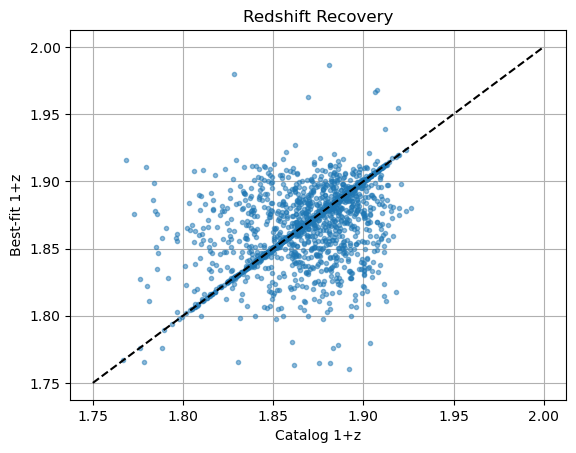

In [87]:
plt.plot(1+all_z[:Ncompute], 1+best_z, '.', alpha=0.5)
plt.plot([1+ZMIN, 1+ZMAX], [1+ZMIN, 1+ZMAX], 'k--')
plt.xlabel('Catalog 1+z')
plt.ylabel('Best-fit 1+z')
plt.title('Redshift Recovery')
plt.grid()
plt.show()

(array([  0.,   0.,   3.,   7.,  10.,   8.,  20.,  41.,  31.,  57.,  98.,
        145., 157., 214., 256., 285., 284., 206., 114.,  52.,  11.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([0.75      , 0.75833333, 0.76666667, 0.775     , 0.78333333,
        0.79166667, 0.8       , 0.80833333, 0.81666667, 0.825     ,
        0.83333333, 0.84166667, 0.85      , 0.85833333, 0.86666667,
        0.875     , 0.88333333, 0.89166667, 0.9       , 0.90833333,
        0.91666667, 0.925     , 0.93333333, 0.94166667, 0.95      ,
        0.95833333, 0.96666667, 0.975     , 0.98333333, 0.99166667,
        1.        ]),
 <BarContainer object of 30 artists>)

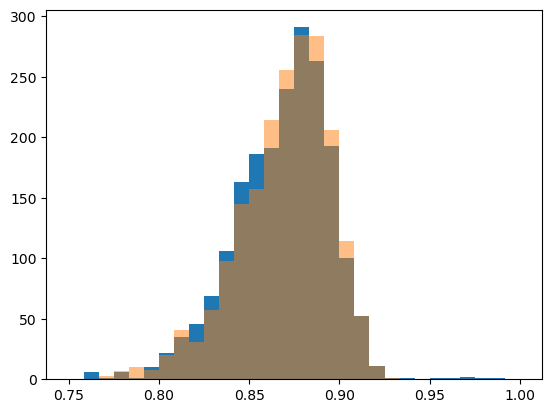

In [88]:
plt.hist(best_z,bins=30,range=(model.zmin,model.zmax),alpha=1)
plt.hist(all_z[:Ncompute],bins=30,range=(model.zmin,model.zmax),alpha=0.5)


## Compute best-fit alpha and template reconstructions

In [89]:
predict_alpha = jax.jit(model.predict_alpha)
best_z_jax = jnp.array(best_z)
alpha = np.array(predict_alpha(params, flux, ivar, best_z_jax))   # (N, Nt)

# Build template array — works for both TemplateModel (params['T']) and NeuralTemplateModel
if isinstance(model, NeuralTemplateModel):
    T_np = np.array(model._build_templates(params))   # (Nt, Nft)
else:
    T_np = np.array(params['T'])                      # (Nt, Nft)
t_wave = np.array(model.t_wave)                       # (Nft,)

def reconstruct(alpha_i, z_i):
    """Interpolate templates and compute prediction for galaxy i."""
    rest_wave = wave_obs / (1.0 + z_i)
    T_z = np.array([np.interp(rest_wave, t_wave, T_np[k]) for k in range(model.Nt)])
    return (alpha_i[:, None] * T_z).sum(axis=0)   # (Nf,)

predictions = np.array([reconstruct(alpha[i], best_z[i]) for i in range(len(ds))])

## Alpha (template amplitude) distributions

Sampled flow prior: (40000, 3)


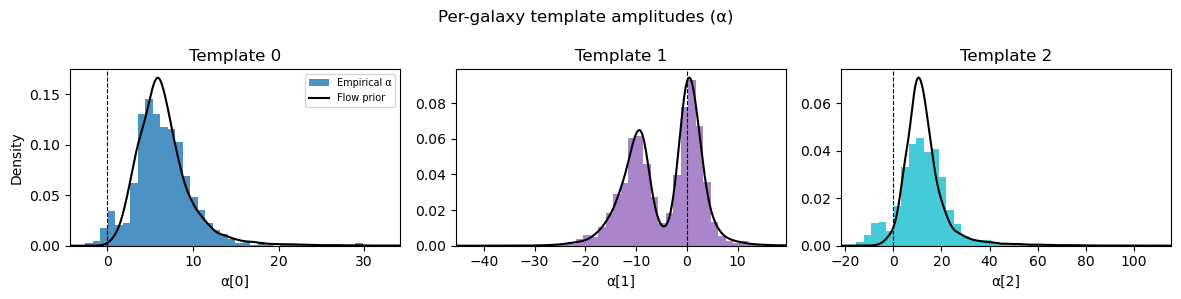

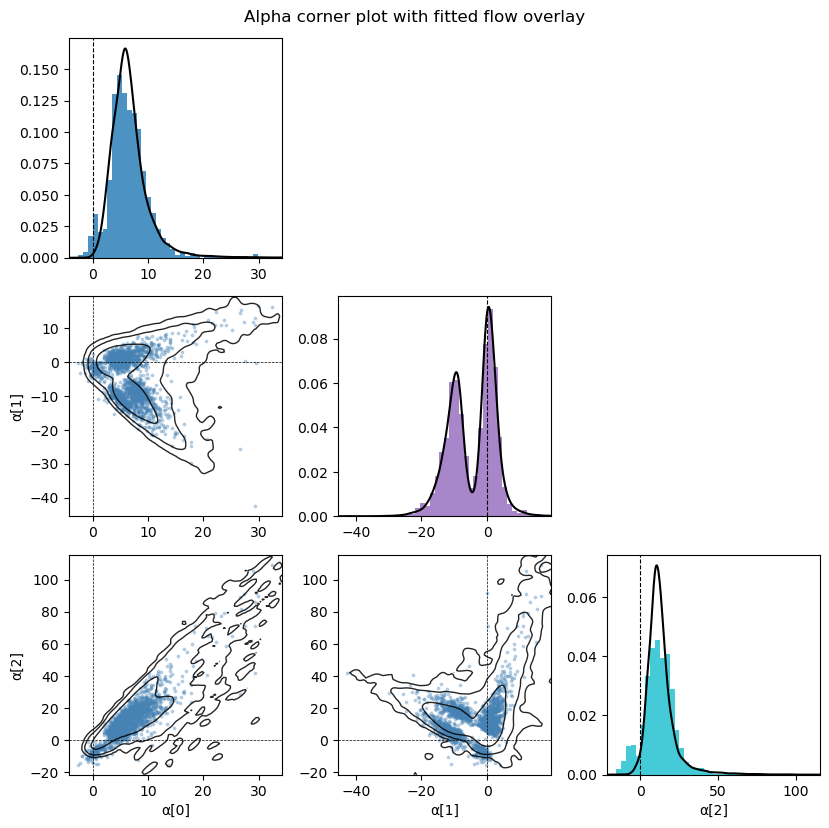

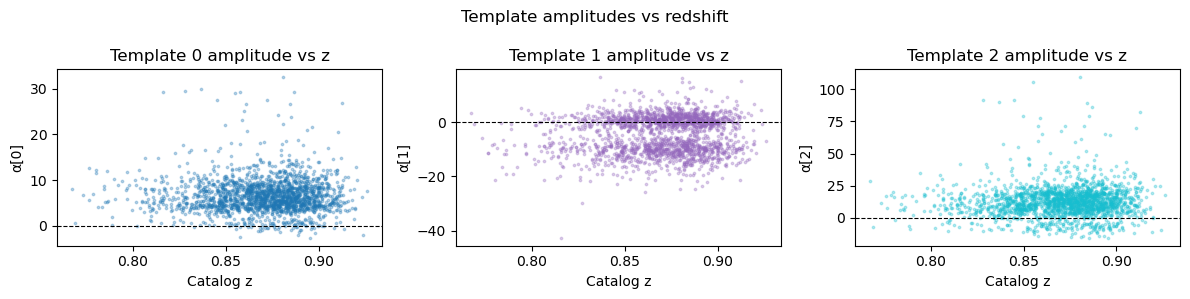

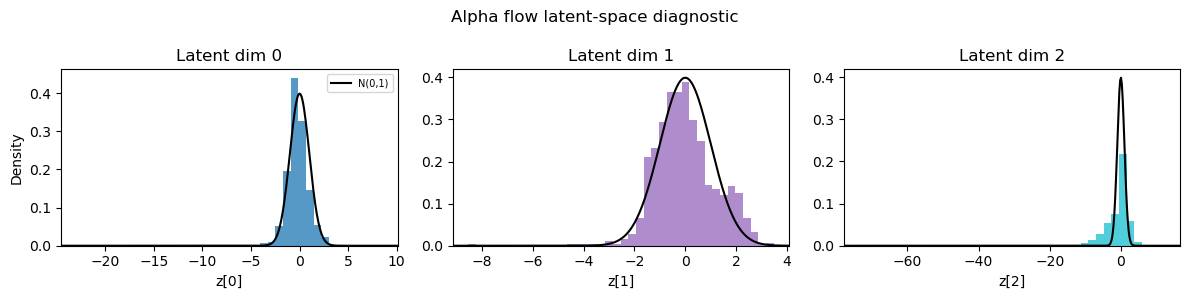

In [90]:
from scipy.stats import norm as _scipy_norm
from scipy.stats import gaussian_kde as _gaussian_kde

colors = plt.cm.tab10(np.linspace(0, 0.9, model.Nt))

_flow_samples = None
_alpha_latent = None
if 'alpha_flow' in params:
    _n_flow_samples = max(20000, 20 * len(alpha))
    _flow_samples = np.array(model.sample_alpha_prior(params, jax.random.PRNGKey(0), _n_flow_samples))
    _alpha_latent = np.array(model.alpha_to_latent(params, jnp.array(alpha)))
    print('Sampled flow prior:', _flow_samples.shape)
else:
    print('No alpha-flow params in checkpoint; skipping fitted-prior overlay.')


def _overlay_flow_1d(ax, dim, x_lo, x_hi, flow_samples):
    xs = np.linspace(x_lo, x_hi, 400)
    vals = flow_samples[:, dim]
    if np.std(vals) < 1e-6:
        ax.axvline(float(vals.mean()), color='k', lw=1.5, label='Flow prior')
        return
    kde = _gaussian_kde(vals)
    ax.plot(xs, kde(xs), 'k-', lw=1.5, label='Flow prior')


def _overlay_flow_2d(ax, dim_x, dim_y, flow_samples):
    vals = flow_samples[:, [dim_x, dim_y]].T
    if np.linalg.matrix_rank(np.cov(vals)) < 2:
        return
    try:
        kde = _gaussian_kde(vals)
    except np.linalg.LinAlgError:
        return
    x_lo, x_hi = ax.get_xlim()
    y_lo, y_hi = ax.get_ylim()
    xx, yy = np.meshgrid(
        np.linspace(x_lo, x_hi, 100),
        np.linspace(y_lo, y_hi, 100),
    )
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    positive = zz[zz > 0]
    if positive.size < 3:
        return
    levels = np.quantile(positive, [0.70, 0.85, 0.95])
    levels = np.unique(levels)
    if levels.size:
        ax.contour(xx, yy, zz, levels=levels, colors='k', linewidths=1.0, alpha=0.85)


# --- 1. 1D marginal histograms per template ----------------------------------
fig, axes = plt.subplots(1, model.Nt, figsize=(4 * model.Nt, 3), sharey=False)
if model.Nt == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    ax.hist(alpha[:, k], bins=40, color=colors[k], alpha=0.8, density=True, label='Empirical α')
    ax.set_xlabel(f'α[{k}]')
    ax.set_ylabel('Density' if k == 0 else '')
    ax.set_title(f'Template {k}')
    ax.axvline(0, color='k', lw=0.8, ls='--')
    if _flow_samples is not None:
        x_lo, x_hi = ax.get_xlim()
        _overlay_flow_1d(ax, k, x_lo, x_hi, _flow_samples)
        ax.set_xlim(x_lo, x_hi)
if _flow_samples is not None:
    axes[0].legend(fontsize=7)
fig.suptitle('Per-galaxy template amplitudes (α)', fontsize=12)
plt.tight_layout()
plt.show()

# --- 2. Pairwise scatter / corner plot ---------------------------------------
if model.Nt > 1:
    fig, axes = plt.subplots(model.Nt, model.Nt,
                             figsize=(2.8 * model.Nt, 2.8 * model.Nt))
    for i in range(model.Nt):
        for j in range(model.Nt):
            ax = axes[i, j]
            if i == j:
                ax.hist(alpha[:, i], bins=40, color=colors[i], alpha=0.8, density=True)
                ax.axvline(0, color='k', lw=0.8, ls='--')
                if _flow_samples is not None:
                    x_lo, x_hi = ax.get_xlim()
                    _overlay_flow_1d(ax, i, x_lo, x_hi, _flow_samples)
                    ax.set_xlim(x_lo, x_hi)
            elif i > j:
                ax.scatter(alpha[:, j], alpha[:, i], s=3, alpha=0.3, color='steelblue')
                ax.axhline(0, color='k', lw=0.5, ls='--')
                ax.axvline(0, color='k', lw=0.5, ls='--')
                if _flow_samples is not None:
                    _overlay_flow_2d(ax, j, i, _flow_samples)
            else:
                ax.set_visible(False)
            if i == model.Nt - 1:
                ax.set_xlabel(f'α[{j}]')
            if j == 0 and i > 0:
                ax.set_ylabel(f'α[{i}]')
    fig.suptitle('Alpha corner plot with fitted flow overlay', fontsize=12)
    plt.tight_layout()
    plt.show()

# --- 3. Alpha vs catalog redshift --------------------------------------------
fig, axes = plt.subplots(1, model.Nt, figsize=(4 * model.Nt, 3), sharey=False)
if model.Nt == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    ax.scatter(all_z[:len(alpha)], alpha[:, k], s=3, alpha=0.3, color=colors[k])
    ax.set_xlabel('Catalog z')
    ax.set_ylabel(f'α[{k}]')
    ax.set_title(f'Template {k} amplitude vs z')
    ax.axhline(0, color='k', lw=0.8, ls='--')
fig.suptitle('Template amplitudes vs redshift', fontsize=12)
plt.tight_layout()
plt.show()

# --- 4. Latent-space check ---------------------------------------------------
if _alpha_latent is not None:
    fig, axes = plt.subplots(1, model.Nt, figsize=(4 * model.Nt, 3), sharey=False)
    if model.Nt == 1:
        axes = [axes]
    for k, ax in enumerate(axes):
        ax.hist(_alpha_latent[:, k], bins=40, density=True, color=colors[k], alpha=0.75)
        x_lo, x_hi = ax.get_xlim()
        xs = np.linspace(x_lo, x_hi, 400)
        ax.plot(xs, _scipy_norm.pdf(xs), 'k-', lw=1.5, label='N(0,1)')
        ax.set_xlim(x_lo, x_hi)
        ax.set_xlabel(f'z[{k}]')
        ax.set_ylabel('Density' if k == 0 else '')
        ax.set_title(f'Latent dim {k}')
    axes[0].legend(fontsize=7)
    fig.suptitle('Alpha flow latent-space diagnostic', fontsize=12)
    plt.tight_layout()
    plt.show()



## Plot spectra with template fits

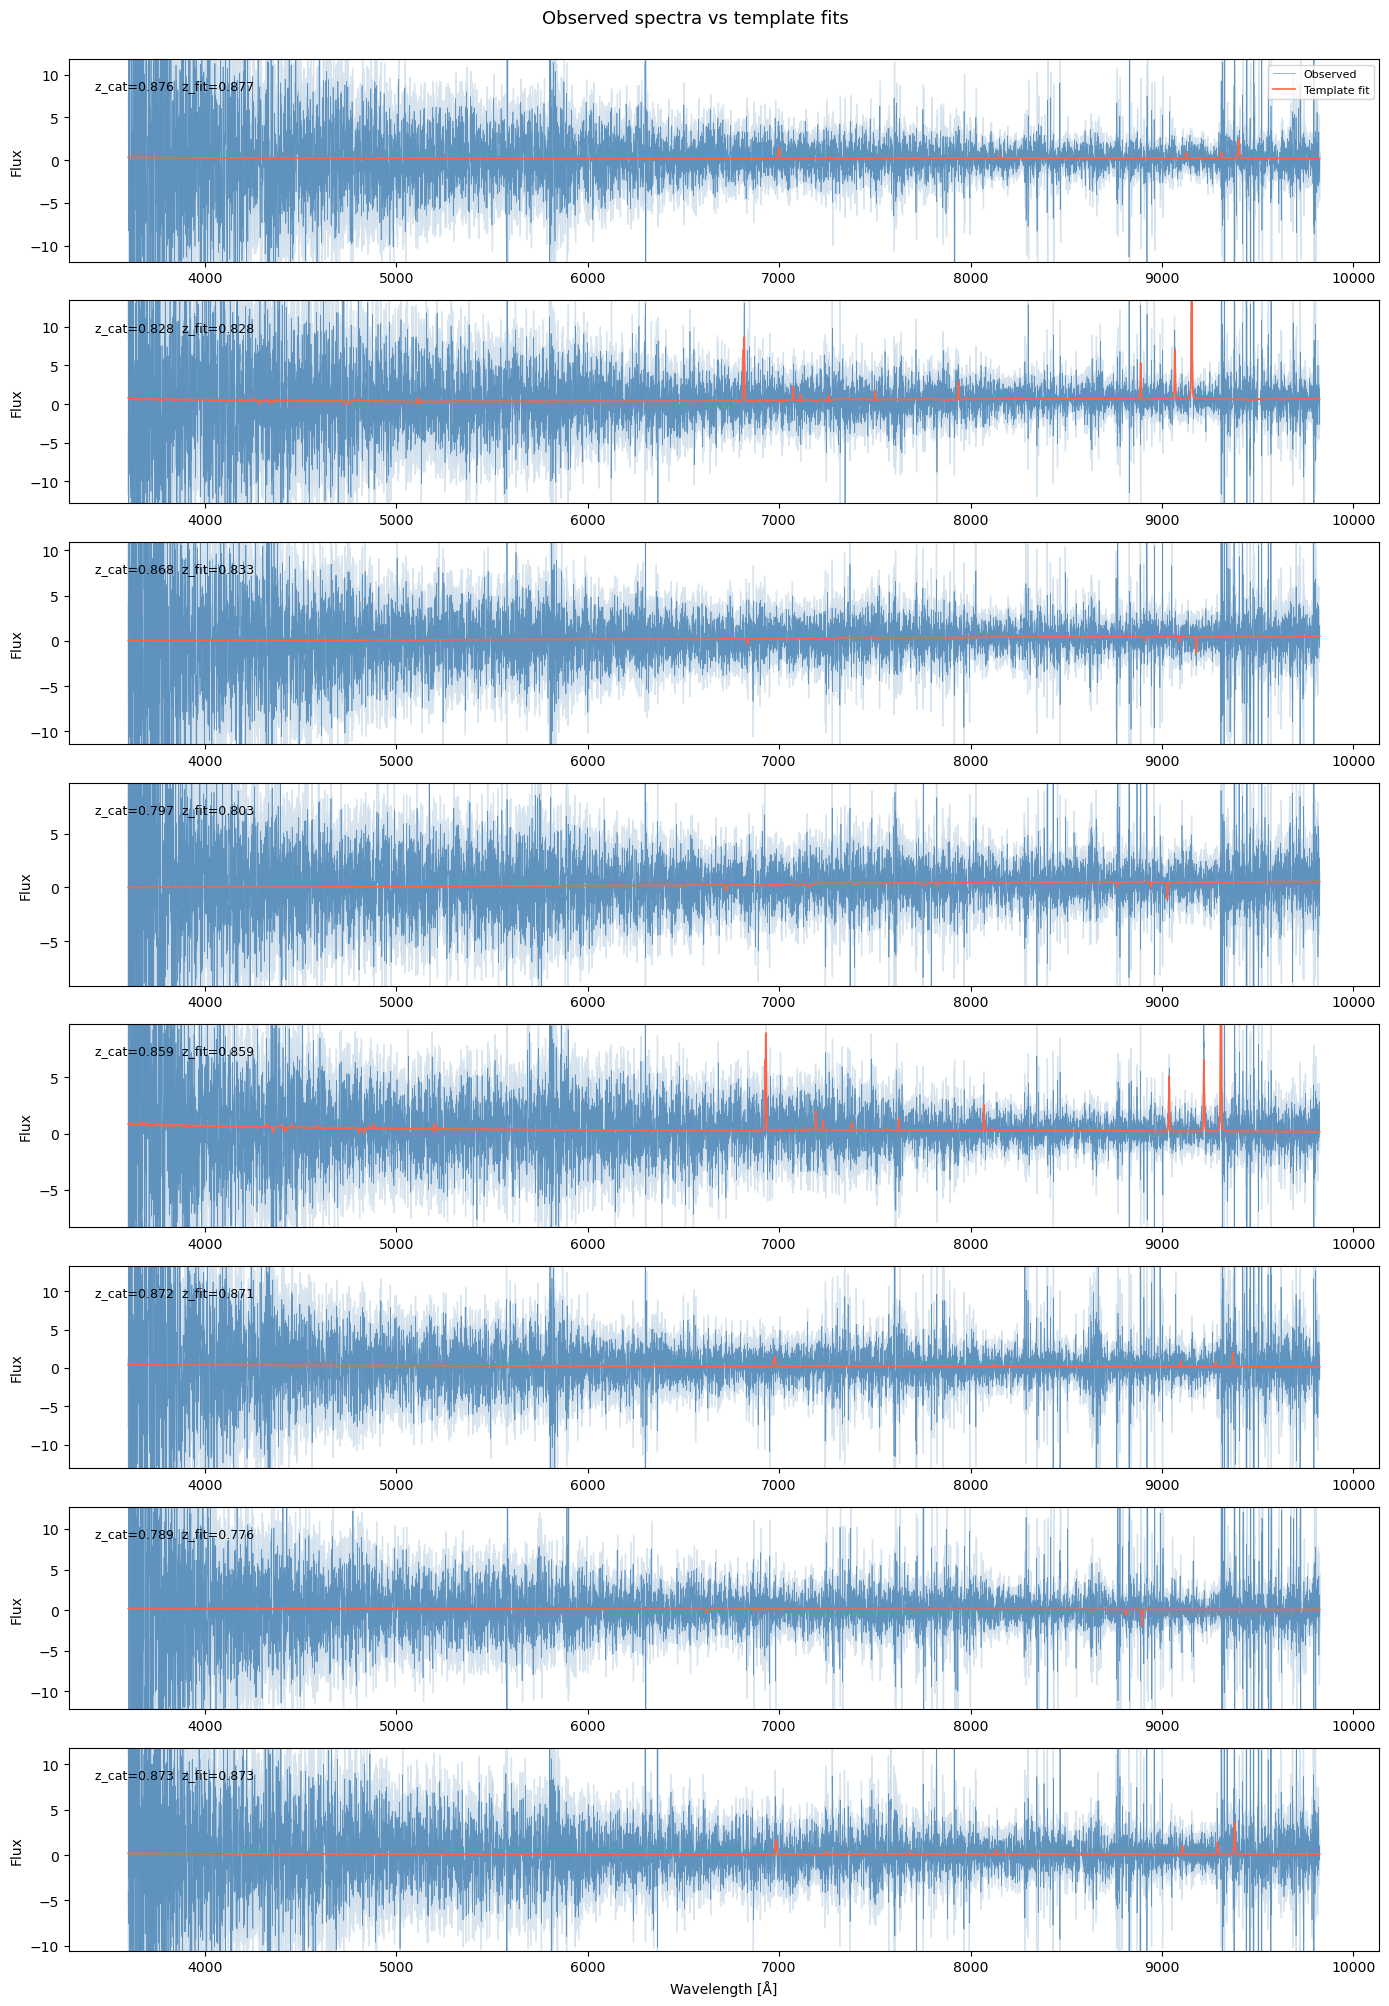

In [91]:
fig, axes = plt.subplots(N_PLOT, 1, figsize=(14, 2.5 * N_PLOT), sharex=False)

#ndx = np.arange(len(axes))
#ndx = np.where(dz > 0.1)[0][:N_PLOT]  # plot examples with large redshift errors
ndx = list(range(N_PLOT-1))+[220]
for i, ax in enumerate(axes):
    fl  = all_flux[ndx[i]]
    iv  = all_ivar[ndx[i]]
    pred = predictions[ndx[i]]
    z_cat = all_z[ndx[i]]
    z_fit = best_z[ndx[i]]

    # 1-sigma error from ivar
    safe_iv = np.where(iv > 0, iv, np.nan)
    sigma   = 1.0 / np.sqrt(safe_iv)

    # Clip y-axis at 5th–99th percentile of valid flux
    valid = fl[iv > 0]
    if len(valid) > 10:
        ylo, yhi = np.percentile(valid, [2, 98])
        pad = 0.15 * (yhi - ylo)
    else:
        ylo, yhi, pad = fl.min(), fl.max(), 0.1

    ax.plot(wave_obs, fl, color='steelblue', lw=0.5, alpha=0.8, label='Observed')
    ax.fill_between(wave_obs, fl - sigma, fl + sigma,
                    color='steelblue', alpha=0.2)
    ax.plot(wave_obs, pred, color='tomato', lw=1.2, label='Template fit')
    ax.set_ylim(ylo - pad, yhi + pad)
    ax.set_ylabel('Flux')
    ax.text(0.02, 0.90,
            f'z_cat={z_cat:.3f}  z_fit={z_fit:.3f}',
            transform=ax.transAxes, fontsize=9, va='top')
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Wavelength [Å]')
fig.suptitle('Observed spectra vs template fits', fontsize=13, y=1.001)
fig.tight_layout()
plt.show()

## Plot z posterior for a single galaxy

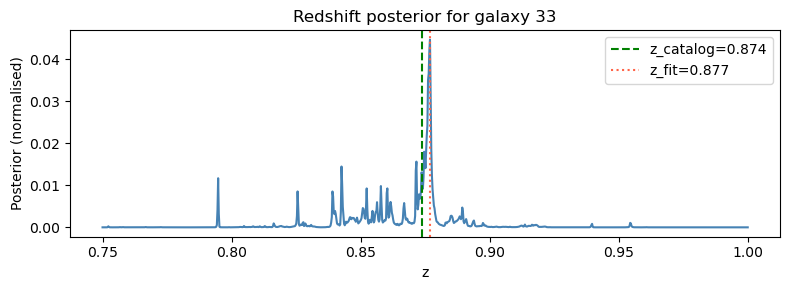

In [92]:
idx = 33  # change to inspect different galaxies
lp = log_post_np[idx]
# Normalise for display
lp_norm = lp - lp.max()
posterior = np.exp(lp_norm)
posterior /= posterior.sum()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(zgrid_np, posterior, color='steelblue')
ax.axvline(all_z[idx],  color='green',  lw=1.5, ls='--', label=f'z_catalog={all_z[idx]:.3f}')
ax.axvline(best_z[idx], color='tomato', lw=1.5, ls=':',  label=f'z_fit={best_z[idx]:.3f}')
ax.set_xlabel('z')
ax.set_ylabel('Posterior (normalised)')
ax.set_title(f'Redshift posterior for galaxy {idx}')
#plt.xlim(all_z[idx] - 0.01,all_z[idx] + 0.01)
ax.legend()
#plt.semilogy()
plt.tight_layout()
plt.show()

## Recovered n(z) vs true redshift histogram

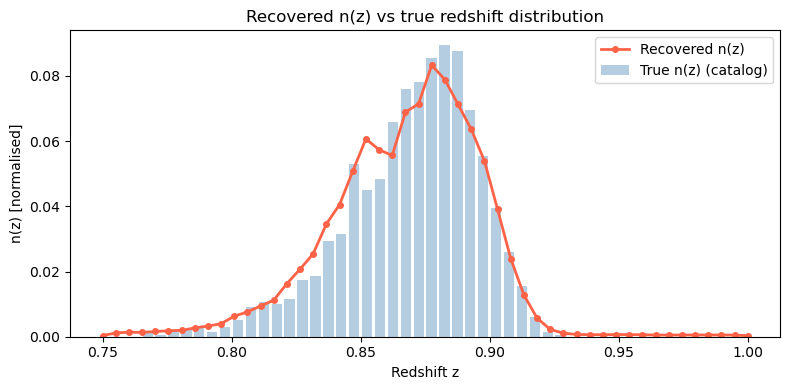

In [93]:
log_nz_raw = np.array(params['log_nz_raw'])
log_nz_norm = log_nz_raw - np.log(np.sum(np.exp(log_nz_raw - log_nz_raw.max()))) - log_nz_raw.max()
nz_recovered = np.exp(log_nz_norm)
nz_recovered /= nz_recovered.sum()   # ensure exact normalisation

z_nz_grid = np.array(model.z_nz_grid)

fig, ax = plt.subplots(figsize=(8, 4))

# True histogram
bins = np.linspace(model.zmin, model.zmax, model.Nnz + 1)
counts, edges = np.histogram(all_z, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
true_nz = counts / counts.sum()
ax.bar(centers, true_nz,
       width=(edges[1] - edges[0]) * 0.8,
       alpha=0.4, color='steelblue', label='True n(z) (catalog)')

# Recovered n(z)
ax.plot(z_nz_grid, nz_recovered, color='tomato', lw=2, marker='o', ms=4,
        label='Recovered n(z)')

ax.set_xlabel('Redshift z')
ax.set_ylabel('n(z) [normalised]')
ax.set_title('Recovered n(z) vs true redshift distribution')
ax.legend()
plt.tight_layout()
plt.show()

## Template shapes

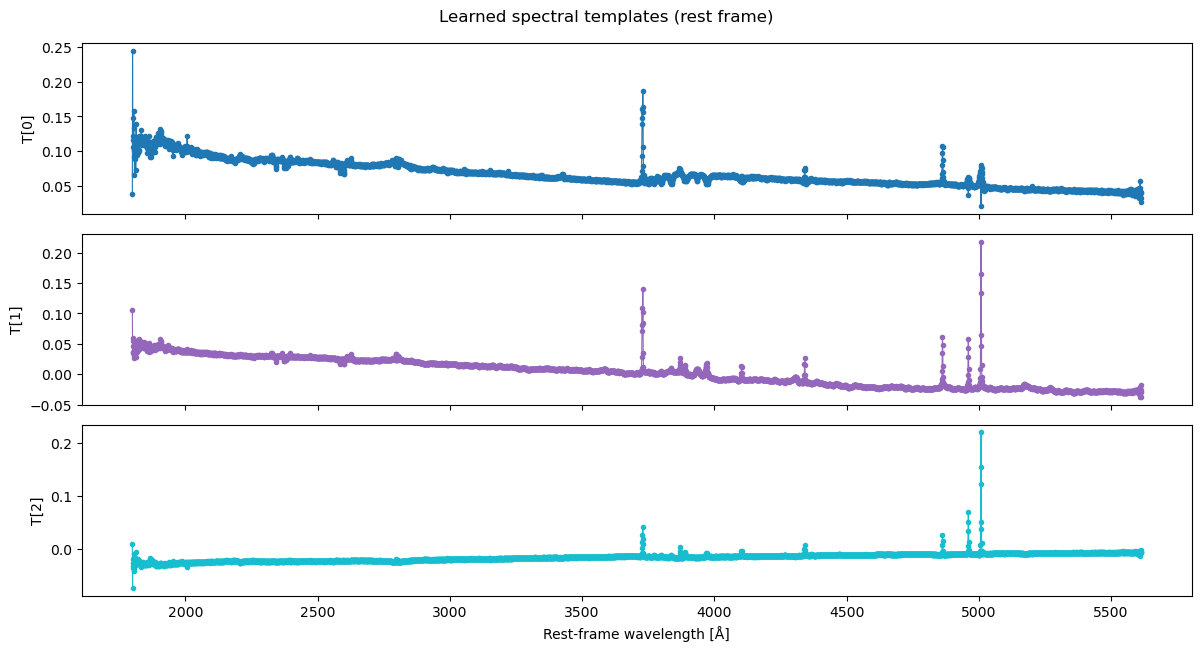

In [52]:
PLOT_O2 = False
fig, axes = plt.subplots(model.Nt, 1, figsize=(12, 2.2 * model.Nt), sharex=True)
if model.Nt == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 0.9, model.Nt))
for k, ax in enumerate(axes):
    ax.plot(t_wave, T_np[k], '.-',color=colors[k], lw=0.8)
    ax.set_ylabel(f'T[{k}]')
    if PLOT_O2:
        ax.set_xlim(3700,3800)
        ax.axvline(3727.09, color='gray', lw=0.5, ls='--')
        ax.axvline(3729.88, color='gray', lw=0.5, ls='--')
axes[-1].set_xlabel('Rest-frame wavelength [Å]')
fig.suptitle('Learned spectral templates (rest frame)', fontsize=12)
plt.tight_layout()
plt.show()

## Template shifted to observed frame

Show each template evaluated at the median redshift of the sample, overlaid on the mean spectrum.

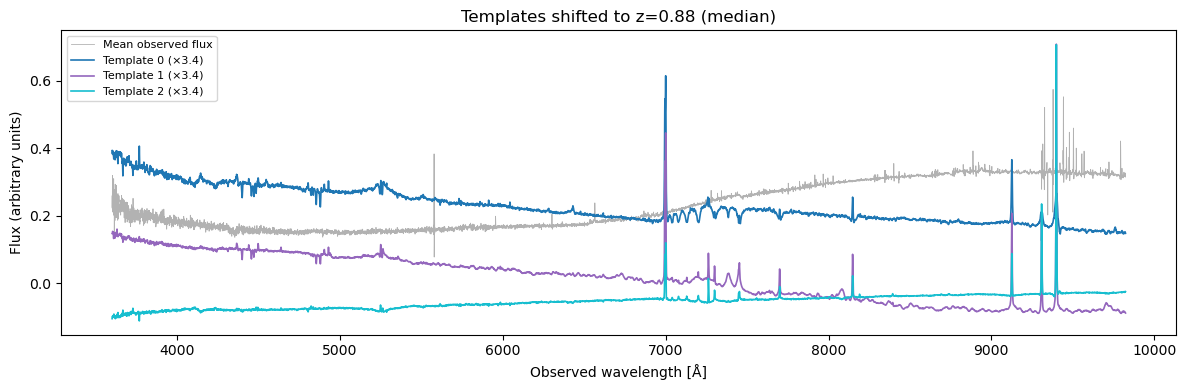

In [16]:
z_median = float(np.median(all_z))
mean_flux = all_flux.mean(axis=0)

# Interpolate each template to observed frame at z_median
rest_wave_med = wave_obs / (1.0 + z_median)
T_at_z = np.array([np.interp(rest_wave_med, t_wave, T_np[k]) for k in range(model.Nt)])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wave_obs, mean_flux, color='gray', lw=0.6, alpha=0.6, label='Mean observed flux')

# Scale templates to match mean flux level for display
scale = mean_flux[mean_flux > 0].mean() / (T_at_z[0][T_at_z[0] > 0].mean() + 1e-10)
for k in range(model.Nt):
    ax.plot(wave_obs, T_at_z[k] * scale, color=colors[k], lw=1.2,
            label=f'Template {k} (×{scale:.1f})')

ax.set_xlabel('Observed wavelength [Å]')
ax.set_ylabel('Flux (arbitrary units)')
ax.set_title(f'Templates shifted to z={z_median:.2f} (median)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

: 